# Distributional RL


In [12]:
# Если библиотек нет, раскомментируй эту ячейку и выполни её один раз:
!pip install gymnasium[box2d] torch matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 83.0 MB/s eta 0:00:00


In [2]:
import random
from collections import deque, namedtuple
from dataclasses import dataclass

import gymnasium as gym
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## Replay Buffer

In [4]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states = torch.tensor(np.array([x.state for x in batch]), dtype=torch.float32, device=device)
        actions = torch.tensor([x.action for x in batch], dtype=torch.long, device=device)
        rewards = torch.tensor([x.reward for x in batch], dtype=torch.float32, device=device)
        next_states = torch.tensor(np.array([x.next_state for x in batch]), dtype=torch.float32, device=device)
        dones = torch.tensor([x.done for x in batch], dtype=torch.float32, device=device)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

## Нейронная сеть C51

In [5]:
class C51Network(nn.Module):
    def __init__(self, state_dim, action_dim, num_atoms=51, hidden_layers=(128, 128)):
        super().__init__()
        self.action_dim = action_dim
        self.num_atoms = num_atoms

        layers = []
        prev_dim = state_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            prev_dim = hidden_dim

        self.feature_layer = nn.Sequential(*layers)
        self.output_layer = nn.Linear(prev_dim, action_dim * num_atoms)

    def forward(self, x):
        x = self.feature_layer(x)
        logits = self.output_layer(x)
        logits = logits.view(-1, self.action_dim, self.num_atoms)
        probs = torch.softmax(logits, dim=2)
        probs = probs.clamp(min=1e-8)
        return probs

    def q_values(self, x, support):
        probs = self.forward(x)
        return torch.sum(probs * support.view(1, 1, -1), dim=2)

In [6]:
def project_distribution_fast(next_dist, rewards, dones, gamma, support, v_min, v_max):

    batch_size = rewards.size(0)
    num_atoms = support.size(0)
    delta_z = (v_max - v_min) / (num_atoms - 1)

    tz = rewards.unsqueeze(1) + (1.0 - dones.unsqueeze(1)) * gamma * support.view(1, -1)
    tz = tz.clamp(v_min, v_max)

    b = (tz - v_min) / delta_z
    lower = b.floor().long()
    upper = b.ceil().long()

    projected = torch.zeros(batch_size, num_atoms, device=device)

    offset = (torch.arange(batch_size, device=device) * num_atoms).unsqueeze(1)
    lower_index = (lower + offset).view(-1)
    upper_index = (upper + offset).view(-1)

    next_dist_flat = next_dist.view(-1)
    lower_weight = (upper.float() - b).view(-1)
    upper_weight = (b - lower.float()).view(-1)

    same_atom = (lower == upper).view(-1)
    lower_weight[same_atom] = 1.0
    upper_weight[same_atom] = 0.0

    projected.view(-1).index_add_(0, lower_index, next_dist_flat * lower_weight)
    projected.view(-1).index_add_(0, upper_index, next_dist_flat * upper_weight)

    projected = projected / projected.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return projected

## Настройки экспериментов

In [7]:
@dataclass
class EnvConfig:
    env_name: str
    episodes: int
    max_steps: int
    hidden_layers: tuple
    lr: float
    gamma: float
    batch_size: int
    buffer_size: int
    learning_starts: int
    target_update: int
    train_freq: int
    epsilon_start: float
    epsilon_end: float
    epsilon_decay: float
    v_min: float
    v_max: float
    num_atoms: int
    reward_shaping: bool = False
    normalize_state: bool = False
    double_dqn: bool = False


FAST_CONFIGS = {
    "LunarLander-v3": EnvConfig(
        env_name="LunarLander-v3",
        episodes=250,
        max_steps=1000,
        hidden_layers=(128, 128),
        lr=1e-3,
        gamma=0.99,
        batch_size=64,
        buffer_size=50_000,
        learning_starts=1000,
        target_update=500,
        train_freq=4,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.99,
        v_min=-200,
        v_max=300,
        num_atoms=51,
        reward_shaping=False,
        normalize_state=False,
        double_dqn=False,
    ),
    "MountainCar-v0": EnvConfig(
        env_name="MountainCar-v0",
        episodes=500,
        max_steps=200,
        hidden_layers=(128, 128),
        lr=7e-4,
        gamma=0.99,
        batch_size=128,
        buffer_size=50_000,
        learning_starts=500,
        target_update=500,
        train_freq=1,
        epsilon_start=1.0,
        epsilon_end=0.01,
        epsilon_decay=0.985,
        v_min=-200,
        v_max=0,
        num_atoms=51,
        reward_shaping=True,
        normalize_state=True,
        double_dqn=False,
    ),
}


In [8]:
def normalize_mountain_car_state(state):
    pos, vel = state
    pos_norm = (pos + 1.2) / 1.8
    vel_norm = (vel + 0.07) / 0.14
    return np.array([pos_norm, vel_norm], dtype=np.float32)


def preprocess_state(state, config):
    state = np.array(state, dtype=np.float32)
    if config.env_name == "MountainCar-v0" and config.normalize_state:
        return normalize_mountain_car_state(state)
    return state


def shape_reward(env_name, state, action, reward, next_state, done):
    if env_name != "MountainCar-v0":
        return reward

    pos, vel = next_state
    shaped = reward

    shaped += 10.0 * abs(vel)
    shaped += 2.0 * (pos + 0.5)

    if done and pos >= 0.5:
        shaped += 100.0

    return shaped

## Обучение C51

In [9]:
def select_action(state, env, policy_net, support, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()

    state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = policy_net.q_values(state_t, support)
    return int(q_values.argmax(dim=1).item())


def train_c51(config, seed=SEED):
    set_seed(seed)

    env = gym.make(config.env_name)
    env.action_space.seed(seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    support = torch.linspace(config.v_min, config.v_max, config.num_atoms, device=device)

    policy_net = C51Network(
        state_dim=state_dim,
        action_dim=action_dim,
        num_atoms=config.num_atoms,
        hidden_layers=config.hidden_layers,
    ).to(device)

    target_net = C51Network(
        state_dim=state_dim,
        action_dim=action_dim,
        num_atoms=config.num_atoms,
        hidden_layers=config.hidden_layers,
    ).to(device)

    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=config.lr)
    replay_buffer = ReplayBuffer(config.buffer_size)

    rewards_history = []
    losses_history = []
    epsilon_history = []

    epsilon = config.epsilon_start
    global_step = 0

    for episode in range(1, config.episodes + 1):
        state, _ = env.reset(seed=seed + episode)
        raw_state = np.array(state, dtype=np.float32)
        state = preprocess_state(raw_state, config)

        episode_reward = 0.0
        episode_losses = []

        for step in range(config.max_steps):
            action = select_action(state, env, policy_net, support, epsilon)

            next_raw_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = preprocess_state(next_raw_state, config)

            train_reward = reward
            if config.reward_shaping:
                train_reward = shape_reward(config.env_name, raw_state, action, reward, next_raw_state, done)

            replay_buffer.push(state, action, train_reward, next_state, done)

            state = next_state
            raw_state = np.array(next_raw_state, dtype=np.float32)
            episode_reward += reward
            global_step += 1

            if len(replay_buffer) >= config.learning_starts and global_step % config.train_freq == 0:
                states, actions, rewards, next_states, dones = replay_buffer.sample(config.batch_size)

                with torch.no_grad():

                    if config.double_dqn:
                        next_q_values = policy_net.q_values(next_states, support)
                    else:
                        next_q_values = target_net.q_values(next_states, support)
                    next_actions = next_q_values.argmax(dim=1)

                    next_dist_all = target_net(next_states)
                    next_dist = next_dist_all[range(config.batch_size), next_actions]

                    target_dist = project_distribution_fast(
                        next_dist=next_dist,
                        rewards=rewards,
                        dones=dones,
                        gamma=config.gamma,
                        support=support,
                        v_min=config.v_min,
                        v_max=config.v_max,
                    )

                current_dist_all = policy_net(states)
                current_dist = current_dist_all[range(config.batch_size), actions]

                loss = -(target_dist * torch.log(current_dist)).sum(dim=1).mean()

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
                optimizer.step()

                episode_losses.append(loss.item())

            if global_step % config.target_update == 0:
                target_net.load_state_dict(policy_net.state_dict())

            if done:
                break

        epsilon = max(config.epsilon_end, epsilon * config.epsilon_decay)

        rewards_history.append(episode_reward)
        losses_history.append(np.mean(episode_losses) if episode_losses else np.nan)
        epsilon_history.append(epsilon)

        if episode % 25 == 0:
            mean_20 = np.mean(rewards_history[-20:])
            print(
                f"{config.env_name} | episode {episode:4d}/{config.episodes} | "
                f"reward={episode_reward:8.2f} | mean20={mean_20:8.2f} | epsilon={epsilon:.3f}"
            )

    env.close()

    return {
        "env_name": config.env_name,
        "config": config,
        "policy_net": policy_net,
        "support": support,
        "rewards": rewards_history,
        "losses": losses_history,
        "epsilons": epsilon_history,
    }

## Запуск экспериментов

In [13]:
results = {}

for env_name, config in FAST_CONFIGS.items():
    print("\n" + "=" * 80)
    print("Training:", env_name)
    print("=" * 80)
    results[env_name] = train_c51(config)


Training: LunarLander-v3
LunarLander-v3 | episode   25/250 | reward= -198.42 | mean20= -191.55 | epsilon=0.778
LunarLander-v3 | episode   50/250 | reward= -126.89 | mean20= -113.76 | epsilon=0.605
LunarLander-v3 | episode   75/250 | reward=  -77.18 | mean20=  -86.25 | epsilon=0.471
LunarLander-v3 | episode  100/250 | reward= -133.80 | mean20=  -62.41 | epsilon=0.366
LunarLander-v3 | episode  125/250 | reward=   83.65 | mean20=   -4.52 | epsilon=0.285
LunarLander-v3 | episode  150/250 | reward=   16.42 | mean20=   45.11 | epsilon=0.221
LunarLander-v3 | episode  175/250 | reward=   78.10 | mean20=   89.04 | epsilon=0.172
LunarLander-v3 | episode  200/250 | reward=  228.25 | mean20=   73.13 | epsilon=0.134
LunarLander-v3 | episode  225/250 | reward=    7.85 | mean20=  137.37 | epsilon=0.104
LunarLander-v3 | episode  250/250 | reward=  172.22 | mean20=  123.51 | epsilon=0.081

Training: MountainCar-v0
MountainCar-v0 | episode   25/500 | reward= -200.00 | mean20= -200.00 | epsilon=0.685
Mo

## Графики обучения

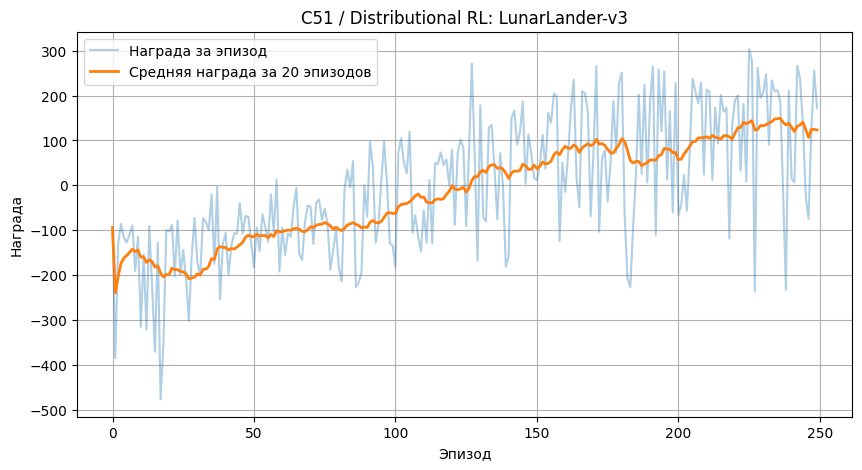

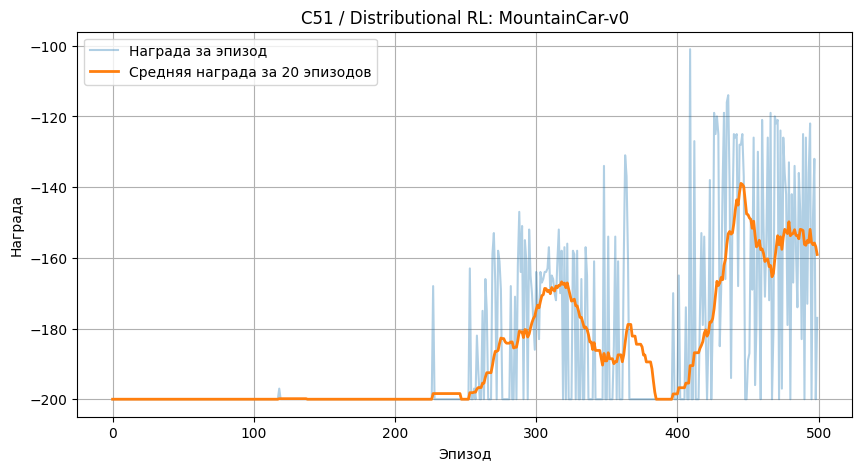

In [14]:
def rolling_mean(values, window=20):
    values = pd.Series(values)
    return values.rolling(window=window, min_periods=1).mean().values


for env_name, result in results.items():
    rewards = result["rewards"]
    smoothed = rolling_mean(rewards, window=20)

    plt.figure(figsize=(10, 5))
    plt.plot(rewards, alpha=0.35, label="Награда за эпизод")
    plt.plot(smoothed, linewidth=2, label="Средняя награда за 20 эпизодов")
    plt.title(f"C51 / Distributional RL: {env_name}")
    plt.xlabel("Эпизод")
    plt.ylabel("Награда")
    plt.legend()
    plt.grid(True)
    plt.show()